In [1]:
from pathlib import Path
import os, fnmatch
import datetime, calendar, time
from pytz import utc
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import pandas as pd
import datetime
import copy
import seaborn as sns
from sklearn.neighbors import KernelDensity

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

# def find_lasso_stats_files(start_dates, root_datadir, in_basename, domain):
#     files = []
#     # Loop over dates
#     for ii in range(0, len(start_dates)):
#         # Get sub-directories (separate runs)
#         idate = start_dates[ii]
#         idirs = list_dirs(f'{root_datadir}/{idate}/')
#         if len(idirs) > 0:
#             for dd in idirs:
#                 # Find track stats file
#                 fname = sorted(glob.glob(f'{dd}/{domain}/stats/{in_basename}*nc'))
#                 if len(fname) > 0:
#                     files.append(fname[0])
#     return files

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                config_dirs = list_dirs(icase)
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    # "20190123",
    "20190125",
    "20190129",
    "20190208",
]

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

# CSAPR data directory
dir_obs = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/'
dir_obs25 = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/'
dir_pixel_obs25 = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_gridded.c1/'
dir_pixel_obs = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqcM1_gridded_convmask.c1/'
terrain_file = f'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/corgridded_terrain.c0/topo_cacti_csapr2_large.nc'
radar_lat = -32.1264
radar_lon = -64.7284
# Start/end hours for OBS
# shour_obs = '09'
# ehour_obs = '03'
shour_obs = '12'
ehour_obs = '00'

basename_obs = 'csapr_trackstats_'
basename_obs25 = 'trackstats_'
# statsfiles_obs = sorted(glob.glob(f'{dir_obs}{basename_obs}*nc'))
# statsfiles_obs

statsfiles_obs = []
statsfiles_obs25 = []
for idate in start_dates:
    statsfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{basename_obs}{idate}*nc')))
    statsfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{basename_obs25}{idate}*nc')))

print(f'Number of cases (OBS): {len(statsfiles_obs)}')
print(f'Number of cases (OBS 2.5km): {len(statsfiles_obs25)}')
statsfiles_obs, statsfiles_obs25

Number of cases (OBS): 8
Number of cases (OBS 2.5km): 8


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181219.1200_20181220.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190125.1200_20190126.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190129.1200_20190130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190208.1200_20190209.0000.nc'],
 ['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltrackin

In [4]:
# LASSO regridded cloud file basename for calculating total "scan" times
# cld_basename = 'corlasso.cldhamsl.'
cld_basename = 'corlasso_cldhamsl_'

# LASSO tracking directory
rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
# LASSO staged data directory
lassodir = '/gpfs/wolf/cli120/world-shared/d3m088/cacti/staged_runs/'
in_basename = 'trackstats_20'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]

# Find LASSO files
# statsfiles_d2 = find_lasso_stats_files(start_dates, rootdir_meso, in_basename, 'd2')
# statsfiles_d3 = find_lasso_stats_files(start_dates, rootdir_les, in_basename, 'd3')
# statsfiles_d4 = find_lasso_stats_files(start_dates, rootdir_les, in_basename, 'd4_15min')
statsfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
statsfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
statsfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min')

print(f'Number of stats files (D2): {len(statsfiles_d2)}')
print(f'Number of stats files (D3): {len(statsfiles_d3)}')
print(f'Number of stats files (D4): {len(statsfiles_d4)}')
statsfiles_d2, statsfiles_d3, statsfiles_d4

Number of stats files (D2): 22
Number of stats files (D3): 23
Number of stats files (D4): 23


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs16/morr/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs04/morr/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/morr/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs02/morr/d2/stats/trackstats_20181205.1200_20181206.0000.nc',


## Functions to count radar scan times

In [5]:
def get_obs_filetimes(
    data_path,
    data_basename,
    time_format="yyyymodd_hhmm",
):
    """
    Calculate base time (Epoch time) from filenames.

    Args:
        data_path: string
            Data directory name.
        data_basename: string
            Data base name.
        time_format: string (optional, default="yyyymodd_hhmm")
            Specify file time format to extract date/time.
    Returns:
        data_filenames: list
            List of data filenames.
        files_basetime: numpy array
            Array of file base time.
        files_datestring: list
            List of file date string.
        files_timestring: list
            List of file time string.

    """
    # logger = logging.getLogger(__name__)
    # Isolate all possible files
    filenames = sorted(fnmatch.filter(os.listdir(data_path), data_basename + '*'))

    # Loop through files, identifying files within the startdate - enddate interval
    nleadingchar = len(data_basename)

    data_filenames = [None]*len(filenames)
    files_timestring = [None]*len(filenames)
    files_datestring = [None]*len(filenames)
    files_basetime = np.full(len(filenames), -9999, dtype=int)
    files_datetime = []

    yyyy_idx = time_format.find("yyyy")
    mo_idx = time_format.find("mo")
    dd_idx = time_format.find("dd")
    hh_idx = time_format.find("hh")
    mm_idx = time_format.find("mm")
    ss_idx = time_format.find("ss")

    # Add basetime character counts to get the actual date/time string positions
    yyyy_idx = nleadingchar + yyyy_idx
    mo_idx = nleadingchar + mo_idx
    dd_idx = nleadingchar + dd_idx
    hh_idx = nleadingchar + hh_idx if (hh_idx != -1) else None
    mm_idx = nleadingchar + mm_idx if (mm_idx != -1) else None
    ss_idx = nleadingchar + ss_idx if (ss_idx != -1) else None

    # Loop over each file
    for ii, ifile in enumerate(filenames):
        year = ifile[yyyy_idx:yyyy_idx+4]
        month = ifile[mo_idx:mo_idx+2]
        day = ifile[dd_idx:dd_idx+2]
        # If hour, minute, second is not in time_format, assume 0
        hour = ifile[hh_idx:hh_idx+2] if (hh_idx is not None) else '00'
        minute = ifile[mm_idx:mm_idx+2] if (mm_idx is not None) else '00'
        second = ifile[ss_idx:ss_idx+2] if (ss_idx is not None) else '00'

        # Check month, day, hour, minute, second valid values
        if (0 <= int(month) <= 12) & (0 <= int(day) <= 31) & \
           (0 <= int(hour) <= 23) & (0 <= int(minute) <= 59) & (0 <= int(second) <= 59):
            TEMP_filetime = datetime.datetime(int(year), int(month), int(day),
                                            int(hour), int(minute), int(second), tzinfo=utc)
            files_basetime[ii] = calendar.timegm(TEMP_filetime.timetuple())
            TEMP_timestamp = pd.to_datetime(f'{year}{month}{day}.{hour}{minute}{second}', format='%Y%m%d.%H%M%S')
            files_datetime.append(TEMP_timestamp)
        else:
            print(f'File has invalid date/time, will not be included in processing: {ifile}')
            pass
        files_datestring[ii] = year + month + day
        files_timestring[ii] = hour + minute
        data_filenames[ii] = data_path + ifile
    files_datetime = np.array(files_datetime)
    return (
        # data_filenames,
        files_basetime,
        files_datetime,
        # files_datestring,
        # files_timestring,
    )

def count_times_obs(statsfiles, filetimes):
    """
    Count total times for observations
    
    Args:
        statsfiles: list
            List containing stats file names
        filetimes: list
            List containing all file times
            
    Return:
        out_ntimes: int
            Total number of times
    """
    out_ntimes = 0
    # Loop over dates
    for ff in statsfiles:
        # Get start/end times from track stats attribute
        ds = xr.open_dataset(ff)
        _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
        _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
        # Count times within the track period
        _ntimes = np.count_nonzero((filetimes >= _sdate) & (filetimes <= _edate))
        # Add counts
        out_ntimes += _ntimes
        print(ff, _ntimes)

    print(f'Total ntimes: {out_ntimes}')
    return out_ntimes

## Count total number of radar scan times from convective masks

In [6]:
# Get datetimes from OBS pixel files
basename_obs = 'taranis_corcsapr2cfrppiqcM1_convmask.c1.'
basetimes_obs, filetimes_obs = get_obs_filetimes(dir_pixel_obs, basename_obs, time_format="yyyymodd_hhmmss")

In [7]:
# Get datetimes from OBS 2.5km pixel files
basename_obs25 = 'taranis_corcsapr2cfrppiqc2500mM1.c1.'
basetimes_obs25, filetimes_obs25 = get_obs_filetimes(dir_pixel_obs25, basename_obs25, time_format="yyyymodd_hhmmss")

In [8]:
# Count total scan times (OBS 500m)
ntimes_o = count_times_obs(statsfiles_obs, filetimes_obs)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181129.1200_20181130.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181204.1200_20181205.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181205.1200_20181206.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181219.1200_20181220.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190122.1200_20190123.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190125.1200_20190126.0000.nc 29
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190129.1200_20190130.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190208.1200_20190209.0000.nc 34
Total ntimes: 351


In [9]:
# Count total scan times (OBS 2.5km)
ntimes_o25 = count_times_obs(statsfiles_obs25, filetimes_obs25)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181219.1200_20181220.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc 48
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc 29
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstat

## Functions to count LASSO file times (equivalent to radar scan times)

In [10]:
def count_times_lasso(statsfiles, frequency):
    """
    Count total times for all LASSO ensemble runs
    
    Args:
        statsfiles: list
            List containing stats file names
        frequency: string
            Frequency to generate time series
            
    Return:
        out_ntimes: int
            Total number of times
    """
    out_ntimes = 0
    for ff in range(len(statsfiles)):
        # Get start/end times from track stats attribute
        ds = xr.open_dataset(statsfiles[ff])
        _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
        _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
        # Generate times within the track period based on input frequency
        _datetimes = pd.date_range(_sdate, _edate, freq=frequency)
        # Count times within the track period
        _ntimes = len(_datetimes)
        print(statsfiles[ff], _ntimes)
        # Add 
        out_ntimes += _ntimes

    print(f'Total ntimes: {out_ntimes}')
    return out_ntimes

In [11]:
# def find_lasso_run_files(dirname, basename, domain):
#     """
#     Find LASSO files in a given case directory
    
#     Args:
#         dirname: string
#             Directory for the case date
#         basename: string
#             LASSO file basename
#         domain: string
#             LASSO domain name (e.g., 'd3', 'd4')
            
#     Return:
#         files: list
#             List containing file names
#     """
#     # Find sub-directories (ensemble runs)
#     p = Path(f'{dirname}')
#     run_dirs = [f for f in p.iterdir() if f.is_dir()]
    
#     # Loop over each ensemble member
#     files = []
#     for dd in run_dirs:
#         # Set sub-directory containing the files
#         _dir = dd / domain / 'run'
#         # Find all files and append to the list
#         files.append(sorted(_dir.glob(f'{basename}*nc')))
#     return files

# def get_lasso_run_filetimes(start_dates, rootdir, basename, domain):
#     """
#     Get LASSO file times in each ensemble run directory
    
#     Args:
#         start_dates: list
#             Case date list (e.g., ['20181129','20190120'])
#         rootdir: string
#             Root directory containing the data
#         basename: string
#             LASSO file basename
#         domain: string
#             LASSO domain name (e.g., 'd3', 'd4')
            
#     Return:
#         filetimes: list
#             List containing file times for each ensemble run
#     """

#     filetimes = []
#     for idate in start_dates:
#         # print(idate)
#         # Find all files for this date (all ensemble members)
#         date_files = find_lasso_run_files(f'{rootdir}{idate}', basename, domain)

#         # Loop over each ensemble member
#         for irun in range(len(date_files)):
#             ifiles = date_files[irun]
#             # print(ifiles[0])

#             # Loop over each file
#             itimes = []
#             for f in ifiles:
#                 # The last 15 characters of a filename (.stem) is date and time
#                 itimes.append(pd.to_datetime(f'{f.stem[-15:]}', format='%Y%m%d.%H%M%S'))
#             # Append times to list
#             filetimes.append(np.array(itimes))
#     return filetimes

# def count_times_lasso(statsfiles, filetimes):
#     """
#     Count total times for all LASSO ensemble runs
    
#     Args:
#         statsfiles: list
#             List containing stats file names
#         filetimes: list
#             List containing all file times for each ensemble run
            
#     Return:
#         out_ntimes: int
#             Total number of times
#     """
#     out_ntimes = 0
#     for ff in range(len(statsfiles)):
#         # Get filetimes
#         _ftimes = filetimes[ff]

#         # Get start/end times from track stats attribute
#         ds = xr.open_dataset(statsfiles[ff])
#         _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
#         _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
#         # Count times within the track period
#         _ntimes = np.count_nonzero((_ftimes >= _sdate) & (_ftimes <= _edate))
#         print(statsfiles[ff], _ntimes)
#         # Add 
#         out_ntimes += _ntimes

#     print(f'Total ntimes: {out_ntimes}')
#     return out_ntimes

## Count LASSO "scan" times

In [12]:
# statsfiles_d2

In [13]:
# _dir = statsfiles_d2[0].replace(f'{rootdir_meso}/', '')
# _dir_parts = _dir.split('/')
# print(_dir_parts)
# _casedate = _dir_parts[0]
# _enmem = _dir_parts[1]
# _config = _dir_parts[2]
# _domain = _dir_parts[3]
# print(_casedate, _enmem, _config, _domain)

# print(f'{lassodir}{_casedate}/{_enmem}/{_config}/meso/subset_{_domain}/{cld_basename}')

In [14]:
# statsfiles_d4

In [15]:
# ds = xr.open_dataset(statsfiles_d2[0])
# # ds.attrs['startdate']
# _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
# _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
# len(pd.date_range(_sdate, _edate, freq='15min'))

In [16]:
# Get LASSO file datetimes (d2)
ntimes_d2 = count_times_lasso(statsfiles_d2, '15min')

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs16/morr/d2/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs04/morr/d2/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/morr/d2/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs02/morr/d2/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf/atm13

In [17]:
# Count d3 scan times
ntimes_d3 = count_times_lasso(statsfiles_d3, '15min')

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base/d3/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base/d3/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs16/morr/d3/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs04/morr/d3/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base/d3/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/morr/d3/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/base/d3/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181205/gefs02/morr/d3/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf/atm131/proj-s

In [18]:
# Count d4 scan times
ntimes_d4 = count_times_lasso(statsfiles_d4, '15min')

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs16/morr/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs04/morr/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/morr/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/base/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181205/gefs02/morr/d4_15min/stats/trackstats_20181205.1

In [19]:
# # Get LASSO file datetimes (d2)
# filetimes_d2 = get_lasso_run_filetimes(start_dates, rootdir_meso, cld_basename, 'd2')

In [20]:
# # Get LASSO file datetimes (d3)
# filetimes_d3 = get_lasso_run_filetimes(start_dates, rootdir_les, cld_basename, 'd3')

In [21]:
# # Get LASSO file datetimes (d4)
# refl_basename = 'reg_refl_'
# filetimes_d4 = get_lasso_run_filetimes(start_dates, rootdir_les, refl_basename, 'd4_15min')

In [22]:
# # Count d2 scan times
# ntimes_d2 = count_times_lasso(statsfiles_d2, filetimes_d2)

In [23]:
# # Count d3 scan times
# ntimes_d3 = count_times_lasso(statsfiles_d3, filetimes_d3)

In [24]:
# # Count d4 scan times
# ntimes_d4 = count_times_lasso(statsfiles_d4, filetimes_d4)

### Read topography file

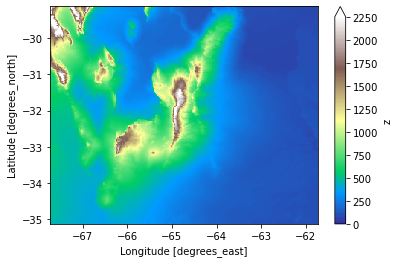

In [25]:
terr = xr.open_dataset(terrain_file)
topoZ = terr['z']
topoLon = terr['x']
topoLat = terr['y']
topoZ.plot(vmin=0, vmax=2250, cmap='terrain')

## Read track stats files

In [26]:
# Read data (OBS)
ds_o = xr.open_mfdataset(statsfiles_obs, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_o = ds_o.sizes['tracks']
ds_o['tracks'] = np.arange(0, ntracks_o)
print(f'Number of tracks (OBS): {ntracks_o}')

Number of tracks (OBS): 526


In [27]:
# Read data (OBS 2.5km)
ds_o25 = xr.open_mfdataset(statsfiles_obs25, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_o25 = ds_o25.sizes['tracks']
ds_o25['tracks'] = np.arange(0, ntracks_o25)
print(f'Number of tracks (OBS 2.5km): {ntracks_o25}')

Number of tracks (OBS 2.5km): 493


In [28]:
# Read data (LASSO D2)
ds_d2 = xr.open_mfdataset(statsfiles_d2, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 5875


In [29]:
# Read data (LASSO D3)
ds_d3 = xr.open_mfdataset(statsfiles_d3, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 7344


## Subset D2, D3 tracks within D4 domain

In [30]:
# Get track min/max lat/lon
minlon_d2 = ds_d2.meanlon.min(dim='times')
maxlon_d2 = ds_d2.meanlon.max(dim='times')
minlat_d2 = ds_d2.meanlat.min(dim='times')
maxlat_d2 = ds_d2.meanlat.max(dim='times')
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 4589


In [31]:
# Get track min/max lat/lon
minlon_d3 = ds_d3.meanlon.min(dim='times')
maxlon_d3 = ds_d3.meanlon.max(dim='times')
minlat_d3 = ds_d3.meanlat.min(dim='times')
maxlat_d3 = ds_d3.meanlat.max(dim='times')
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 5794


In [32]:
# Read data (LASSO D4)
ds_d4 = xr.open_mfdataset(statsfiles_d4, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 5530


## Get variables for analysis

In [33]:
time_res_o25 = ds_o25.attrs['time_resolution_hour']
pixel_radius_o25 = ds_o25.attrs['pixel_radius_km']
lifetime_o25 = ds_o25['track_duration'] * time_res_o25

start_time_o25 = ds_o25['start_basetime']
end_time_o25 = ds_o25['end_basetime']
end_merge_tracknumber_o25 = ds_o25['end_merge_tracknumber']
start_split_tracknumber_o25 = ds_o25['start_split_tracknumber']
cell_lon_o25 = ds_o25['cell_meanlon']
cell_lat_o25 = ds_o25['cell_meanlat']
cell_area_o25 = ds_o25['cell_area']
maxrange_flag_o25 = ds_o25['maxrange_flag']

maxdbz_o25 = ds_o25['max_dbz']
eth10_o25 = ds_o25['maxETH_10dbz']
eth20_o25 = ds_o25['maxETH_20dbz']
eth30_o25 = ds_o25['maxETH_30dbz']
eth40_o25 = ds_o25['maxETH_40dbz']
eth50_o25 = ds_o25['maxETH_50dbz']

In [34]:
time_res_o = ds_o.attrs['time_resolution_hour']
pixel_radius_o = ds_o.attrs['pixel_radius_km']
lifetime_o = ds_o['track_duration'] * time_res_o

start_time_o = ds_o['start_basetime']
end_time_o = ds_o['end_basetime']
end_merge_tracknumber_o = ds_o['end_merge_tracknumber']
start_split_tracknumber_o = ds_o['start_split_tracknumber']
cell_lon_o = ds_o['cell_meanlon']
cell_lat_o = ds_o['cell_meanlat']
cell_area_o = ds_o['cell_area']
maxrange_flag_o = ds_o['maxrange_flag']

maxdbz_o = ds_o['max_dbz']
eth10_o = ds_o['maxETH_10dbz']
eth20_o = ds_o['maxETH_20dbz']
eth30_o = ds_o['maxETH_30dbz']
eth40_o = ds_o['maxETH_40dbz']
eth50_o = ds_o['maxETH_50dbz']

In [35]:
time_res_d2 = ds_d2.attrs['time_resolution_hour']
pixel_radius_d2 = ds_d2.attrs['pixel_radius_km']
lifetime_d2 = ds_d2['track_duration'] * time_res_d2

start_time_d2 = ds_d2['start_basetime']
end_time_d2 = ds_d2['end_basetime']
end_merge_tracknumber_d2 = ds_d2['end_merge_tracknumber']
start_split_tracknumber_d2 = ds_d2['start_split_tracknumber']
cell_lon_d2 = ds_d2['cell_meanlon']
cell_lat_d2 = ds_d2['cell_meanlat']
cell_area_d2 = ds_d2['cell_area']
maxrange_flag_d2 = ds_d2['maxrange_flag']

maxdbz_d2 = ds_d2['max_dbz']
eth10_d2 = ds_d2['maxETH_10dbz']
eth20_d2 = ds_d2['maxETH_20dbz']
eth30_d2 = ds_d2['maxETH_30dbz']
eth40_d2 = ds_d2['maxETH_40dbz']
eth50_d2 = ds_d2['maxETH_50dbz']

In [36]:
time_res_d3 = ds_d3.attrs['time_resolution_hour']
pixel_radius_d3 = ds_d3.attrs['pixel_radius_km']
lifetime_d3 = ds_d3['track_duration'] * time_res_d3

start_time_d3 = ds_d3['start_basetime']
end_time_d3 = ds_d3['end_basetime']
end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']
cell_lon_d3 = ds_d3['cell_meanlon']
cell_lat_d3 = ds_d3['cell_meanlat']
cell_area_d3 = ds_d3['cell_area']
maxrange_flag_d3 = ds_d3['maxrange_flag']

maxdbz_d3 = ds_d3['max_dbz']
eth10_d3 = ds_d3['maxETH_10dbz']
eth20_d3 = ds_d3['maxETH_20dbz']
eth30_d3 = ds_d3['maxETH_30dbz']
eth40_d3 = ds_d3['maxETH_40dbz']
eth50_d3 = ds_d3['maxETH_50dbz']

In [37]:
time_res_d4 = ds_d4.attrs['time_resolution_hour']
pixel_radius_d4 = ds_d4.attrs['pixel_radius_km']
lifetime_d4 = ds_d4['track_duration'] * time_res_d4

start_time_d4 = ds_d4['start_basetime']
end_time_d4 = ds_d4['end_basetime']
end_merge_tracknumber_d4 = ds_d4['end_merge_tracknumber']
start_split_tracknumber_d4 = ds_d4['start_split_tracknumber']
cell_lon_d4 = ds_d4['cell_meanlon']
cell_lat_d4 = ds_d4['cell_meanlat']
cell_area_d4 = ds_d4['cell_area']
maxrange_flag_d4 = ds_d4['maxrange_flag']

maxdbz_d4 = ds_d4['max_dbz']
eth10_d4 = ds_d4['maxETH_10dbz']
eth20_d4 = ds_d4['maxETH_20dbz']
eth30_d4 = ds_d4['maxETH_30dbz']
eth40_d4 = ds_d4['maxETH_40dbz']
eth50_d4 = ds_d4['maxETH_50dbz']

## Find merge/split tracks

In [38]:
# Find tracks not end with merge or not start with split
nonmerge_o25 = np.where(np.isnan(end_merge_tracknumber_o25))[0]
nonsplit_o25 = np.where(np.isnan(start_split_tracknumber_o25))[0]
ntracks_nonmerge_o25 = len(nonmerge_o25)
ntracks_nonsplit_o25 = len(nonsplit_o25)
print(f'Number of non-merge tracks (OBS 2.5km): {ntracks_nonmerge_o25}')
print(f'Number of non-split tracks (OBS 2.5km): {ntracks_nonsplit_o25}')

merge_o25 = np.where(end_merge_tracknumber_o25 > 0)[0]
split_o25 = np.where(start_split_tracknumber_o25 > 0)[0]
ntracks_merge_o25 = len(merge_o25)
ntracks_split_o25 = len(split_o25)
print(f'Number of merge tracks (OBS 2.5km): {ntracks_merge_o25}')
print(f'Number of split tracks (OBS 2.5km): {ntracks_split_o25}')

Number of non-merge tracks (OBS 2.5km): 342
Number of non-split tracks (OBS 2.5km): 317
Number of merge tracks (OBS 2.5km): 151
Number of split tracks (OBS 2.5km): 176


In [39]:
# Find tracks not end with merge or not start with split
nonmerge_o = np.where(np.isnan(end_merge_tracknumber_o))[0]
nonsplit_o = np.where(np.isnan(start_split_tracknumber_o))[0]
ntracks_nonmerge_o = len(nonmerge_o)
ntracks_nonsplit_o = len(nonsplit_o)
print(f'Number of non-merge tracks (OBS): {ntracks_nonmerge_o}')
print(f'Number of non-split tracks (OBS): {ntracks_nonsplit_o}')

merge_o = np.where(end_merge_tracknumber_o > 0)[0]
split_o = np.where(start_split_tracknumber_o > 0)[0]
ntracks_merge_o = len(merge_o)
ntracks_split_o = len(split_o)
print(f'Number of merge tracks (OBS): {ntracks_merge_o}')
print(f'Number of split tracks (OBS): {ntracks_split_o}')

Number of non-merge tracks (OBS): 373
Number of non-split tracks (OBS): 346
Number of merge tracks (OBS): 153
Number of split tracks (OBS): 180


In [40]:
# Find tracks not end with merge or not start with split
nonmerge_d2 = np.where(np.isnan(end_merge_tracknumber_d2))[0]
nonsplit_d2 = np.where(np.isnan(start_split_tracknumber_d2))[0]
ntracks_nonmerge_d2 = len(nonmerge_d2)
ntracks_nonsplit_d2 = len(nonsplit_d2)
print(f'Number of non-merge tracks (d2): {ntracks_nonmerge_d2}')
print(f'Number of non-split tracks (d2): {ntracks_nonsplit_d2}')

merge_d2 = np.where(end_merge_tracknumber_d2 > 0)[0]
split_d2 = np.where(start_split_tracknumber_d2 > 0)[0]
ntracks_merge_d2 = len(merge_d2)
ntracks_split_d2 = len(split_d2)
print(f'Number of merge tracks (d2): {ntracks_merge_d2}')
print(f'Number of split tracks (d2): {ntracks_split_d2}')

Number of non-merge tracks (d2): 2511
Number of non-split tracks (d2): 2284
Number of merge tracks (d2): 2078
Number of split tracks (d2): 2305


In [41]:
# Find tracks not end with merge or not start with split
nonmerge_d3 = np.where(np.isnan(end_merge_tracknumber_d3))[0]
nonsplit_d3 = np.where(np.isnan(start_split_tracknumber_d3))[0]
ntracks_nonmerge_d3 = len(nonmerge_d3)
ntracks_nonsplit_d3 = len(nonsplit_d3)
print(f'Number of non-merge tracks (D3): {ntracks_nonmerge_d3}')
print(f'Number of non-split tracks (D3): {ntracks_nonsplit_d3}')

merge_d3 = np.where(end_merge_tracknumber_d3 > 0)[0]
split_d3 = np.where(start_split_tracknumber_d3 > 0)[0]
ntracks_merge_d3 = len(merge_d3)
ntracks_split_d3 = len(split_d3)
print(f'Number of merge tracks (D3): {ntracks_merge_d3}')
print(f'Number of split tracks (D3): {ntracks_split_d3}')

Number of non-merge tracks (D3): 3474
Number of non-split tracks (D3): 3020
Number of merge tracks (D3): 2320
Number of split tracks (D3): 2774


In [42]:
# Find tracks not end with merge or not start with split
nonmerge_d4 = np.where(np.isnan(end_merge_tracknumber_d4))[0]
nonsplit_d4 = np.where(np.isnan(start_split_tracknumber_d4))[0]
ntracks_nonmerge_d4 = len(nonmerge_d4)
ntracks_nonsplit_d4 = len(nonsplit_d4)
print(f'Number of non-merge tracks (D4): {ntracks_nonmerge_d4}')
print(f'Number of non-split tracks (D4): {ntracks_nonsplit_d4}')

merge_d4 = np.where(end_merge_tracknumber_d4 > 0)[0]
split_d4 = np.where(start_split_tracknumber_d4 > 0)[0]
ntracks_merge_d4 = len(merge_d4)
ntracks_split_d4 = len(split_d4)
print(f'Number of merge tracks (D4): {ntracks_merge_d4}')
print(f'Number of split tracks (D4): {ntracks_split_d4}')

Number of non-merge tracks (D4): 3363
Number of non-split tracks (D4): 3159
Number of merge tracks (D4): 2167
Number of split tracks (D4): 2371


## Get cell initiation locations

In [43]:
start_lon_o = cell_lon_o.isel(times=0)
start_lat_o = cell_lat_o.isel(times=0)
start_lon_nonsplit_o = cell_lon_o.isel(tracks=nonsplit_o, times=0)
start_lat_nonsplit_o = cell_lat_o.isel(tracks=nonsplit_o, times=0)

In [44]:
start_lon_o25 = cell_lon_o25.isel(times=0)
start_lat_o25 = cell_lat_o25.isel(times=0)
start_lon_nonsplit_o25 = cell_lon_o25.isel(tracks=nonsplit_o25, times=0)
start_lat_nonsplit_o25 = cell_lat_o25.isel(tracks=nonsplit_o25, times=0)

In [45]:
start_lon_d2 = cell_lon_d2.isel(times=0)
start_lat_d2 = cell_lat_d2.isel(times=0)
start_lon_nonsplit_d2 = cell_lon_d2.isel(tracks=nonsplit_d2, times=0)
start_lat_nonsplit_d2 = cell_lat_d2.isel(tracks=nonsplit_d2, times=0)

In [46]:
start_lon_d3 = cell_lon_d3.isel(times=0)
start_lat_d3 = cell_lat_d3.isel(times=0)
start_lon_nonsplit_d3 = cell_lon_d3.isel(tracks=nonsplit_d3, times=0)
start_lat_nonsplit_d3 = cell_lat_d3.isel(tracks=nonsplit_d3, times=0)

In [47]:
start_lon_d4 = cell_lon_d4.isel(times=0)
start_lat_d4 = cell_lat_d4.isel(times=0)
start_lon_nonsplit_d4 = cell_lon_d4.isel(tracks=nonsplit_d4, times=0)
start_lat_nonsplit_d4 = cell_lat_d4.isel(tracks=nonsplit_d4, times=0)

In [48]:
# buffer = 0.05
# minlon, maxlon = np.nanmin([start_lon_d4.values, end_lon])-buffer, np.nanmax([start_lon_d4.values, end_lon])+buffer
# minlat, maxlat = np.nanmin([start_lat_d4.values, end_lat])-buffer, np.nanmax([start_lat_d4.values, end_lat])+buffer
# print(minlon, maxlon, minlat, maxlat)

## Calculate spatial map of initiation locations

In [49]:
# Set domain boundary based on overlap area between OBS and D4
minlon, maxlon = -65.4, -63.5
minlat, maxlat = -33.1, -31.1
buffer = 0.05
# bins = [24, 24]
ranges = [[minlon+buffer,maxlon-buffer], [minlat+buffer,maxlat-buffer]]

lonbins = np.arange(minlon, maxlon, 0.1)
latbins = np.arange(minlat, maxlat, 0.1)
bins = [lonbins, latbins]

In [50]:
hist2d_startloc_o25, xbins, ybins = np.histogram2d(start_lon_o25.values, start_lat_o25.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_o25, xbins, ybins = np.histogram2d(start_lon_nonsplit_o25.values, start_lat_nonsplit_o25.values, bins=bins, range=ranges)
hist2d_startloc_o25 = hist2d_startloc_o25.transpose()
hist2d_startloc_nonsplit_o25 = hist2d_startloc_nonsplit_o25.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_o25 = 100 * hist2d_startloc_o25 / ntimes_o25
freq2d_startloc_nonsplit_o25 = 100 * hist2d_startloc_nonsplit_o25 / ntimes_o25

In [51]:
hist2d_startloc_o, xbins, ybins = np.histogram2d(start_lon_o.values, start_lat_o.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_o, xbins, ybins = np.histogram2d(start_lon_nonsplit_o.values, start_lat_nonsplit_o.values, bins=bins, range=ranges)
hist2d_startloc_o = hist2d_startloc_o.transpose()
hist2d_startloc_nonsplit_o = hist2d_startloc_nonsplit_o.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_o = 100 * hist2d_startloc_o / ntimes_o
freq2d_startloc_nonsplit_o = 100 * hist2d_startloc_nonsplit_o / ntimes_o

In [52]:
hist2d_startloc_d2, xbins, ybins = np.histogram2d(start_lon_d2.values, start_lat_d2.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d2, xbins, ybins = np.histogram2d(start_lon_nonsplit_d2.values, start_lat_nonsplit_d2.values, bins=bins, range=ranges)
hist2d_startloc_d2 = hist2d_startloc_d2.transpose()
hist2d_startloc_nonsplit_d2 = hist2d_startloc_nonsplit_d2.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d2 = 100 * hist2d_startloc_d2 / ntimes_d2
freq2d_startloc_nonsplit_d2 = 100 * hist2d_startloc_nonsplit_d2 / ntimes_d2

In [53]:
hist2d_startloc_d3, xbins, ybins = np.histogram2d(start_lon_d3.values, start_lat_d3.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d3, xbins, ybins = np.histogram2d(start_lon_nonsplit_d3.values, start_lat_nonsplit_d3.values, bins=bins, range=ranges)
hist2d_startloc_d3 = hist2d_startloc_d3.transpose()
hist2d_startloc_nonsplit_d3 = hist2d_startloc_nonsplit_d3.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d3 = 100 * hist2d_startloc_d3 / ntimes_d3
freq2d_startloc_nonsplit_d3 = 100 * hist2d_startloc_nonsplit_d3 / ntimes_d3

In [54]:
hist2d_startloc_d4, xbins, ybins = np.histogram2d(start_lon_d4.values, start_lat_d4.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d4, xbins, ybins = np.histogram2d(start_lon_nonsplit_d4.values, start_lat_nonsplit_d4.values, bins=bins, range=ranges)
hist2d_startloc_d4 = hist2d_startloc_d4.transpose()
hist2d_startloc_nonsplit_d4 = hist2d_startloc_nonsplit_d4.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d4 = 100 * hist2d_startloc_d4 / ntimes_d4
freq2d_startloc_nonsplit_d4 = 100 * hist2d_startloc_nonsplit_d4 / ntimes_d4

In [55]:
np.diff(xbins), np.diff(ybins)

(array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1, 0.1, 0.1, 0.1]),
 array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1, 0.1, 0.1, 0.1]))

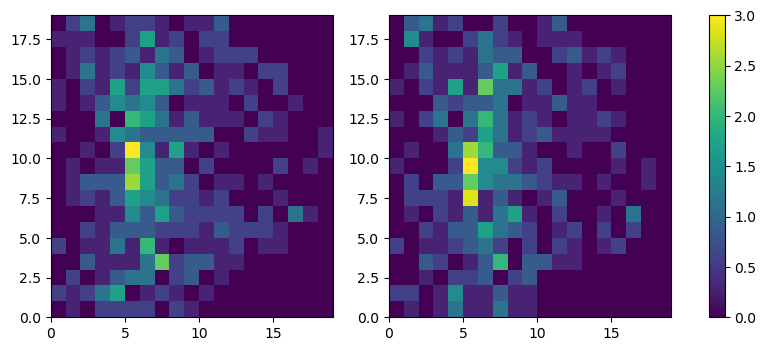

In [56]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
pcm = ax.pcolormesh(freq2d_startloc_o, vmin=0, vmax=3.)
ax = axes[1]
pcm = ax.pcolormesh(freq2d_startloc_o25, vmin=0, vmax=3.)
fig.colorbar(pcm, ax=axes.ravel().tolist())

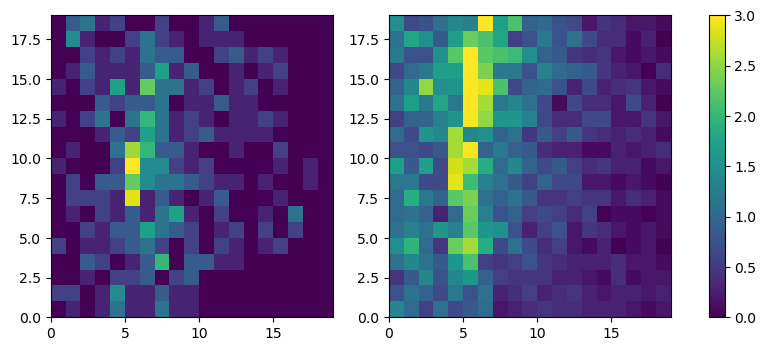

In [57]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
pcm = ax.pcolormesh(freq2d_startloc_o25, vmin=0, vmax=3.)
ax = axes[1]
pcm = ax.pcolormesh(freq2d_startloc_d2, vmin=0, vmax=3.)
fig.colorbar(pcm, ax=axes.ravel().tolist())

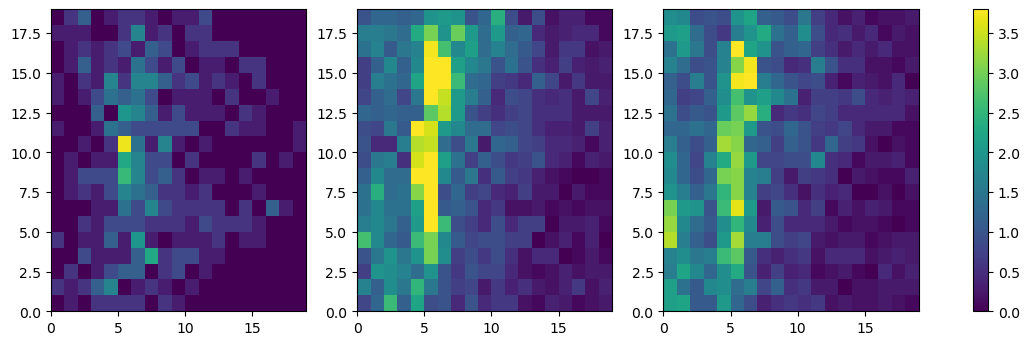

In [58]:
fig, axes = plt.subplots(1, 3, figsize=[14,4], dpi=100)
ax = axes[0]
pcm = ax.pcolormesh(freq2d_startloc_o, vmin=0, vmax=3.8)
ax = axes[1]
pcm = ax.pcolormesh(freq2d_startloc_d3, vmin=0, vmax=3.8)
ax = axes[2]
pcm = ax.pcolormesh(freq2d_startloc_d4, vmin=0, vmax=3.8)
fig.colorbar(pcm, ax=axes.ravel().tolist())

In [59]:
def plot_Nheatmaps(ncol, dataarr, lonarr, latarr, topoZ, topoLon, topoLat, levels, cmaps, cmap_topo, cblabels, cbticks, titles, figname, 
                   eSDC=None, oob_colors=None, figsize=[15.5,5]):
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(1, ncol, figsize=figsize, dpi=100)
    marker_style = dict(color='k', linestyle='none', marker='o', markersize=12, markerfacecolor='red')
    topo_levs = [500,1000,1500,2000,2500]

    for col in range(ncol):
        ax = axes[col]
        Zm = np.ma.masked_where(dataarr[col] == 0, dataarr[col])
        cmap = copy.copy(mpl.cm.get_cmap(cmaps))
        norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
        p1 = ax.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
        ax.set_xlabel('Longitude')
        if (col == 0): ax.set_ylabel('Latitude')
        ax.set_title(titles[col], loc='left')
        ax.set_xlim(np.min(lonarr), np.max(lonarr))
        ax.set_ylim(np.min(latarr), np.max(latarr))
        ax.set_xticks(np.arange(-65., maxlon, 0.5))
        ax.set_yticks(np.arange(-33, maxlat, 0.5))
        ax.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
        ax.plot(radar_lon, radar_lat, **marker_style)
        ax.grid(ls='--')
        if eSDC is not None:
            ax.axvline(x=eSDC, color='magenta', lw=2)
        # Legend for terrain
        custom_lines = [mpl.lines.Line2D([0], [0], color=plt.get_cmap(cmap_topo)(0.8), lw=2)]
        ax.legend(custom_lines, ['Terrain'], loc='upper right')
        # Set out of bound colors
        if oob_colors is not None:
            p1.cmap.set_over(oob_colors['over'])
            p1.cmap.set_under(oob_colors['under'])
            p1.set_clim(min(levels), max(levels))
    
    fig.tight_layout()
    fig.colorbar(p1, ax=axes.ravel().tolist(), ticks=cbticks, pad=0.02, label=cblabels, extend='both')
    fig.savefig(figname, bbox_inches='tight', facecolor='w', dpi=300)
    
    return fig

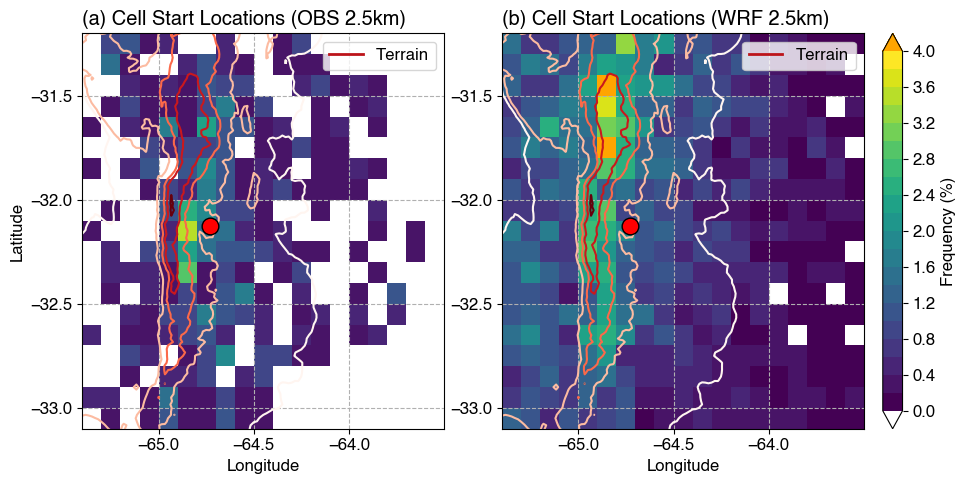

In [60]:
dataarr = [freq2d_startloc_o25, freq2d_startloc_d2]
levels = np.arange(0, 4.01, 0.2)
cbticks = np.arange(0, 4.01, 0.4)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under':'white', 'over':'orange'}
titles = ['(a) Cell Start Locations (OBS 2.5km)', '(b) Cell Start Locations (WRF 2.5km)']
cblabels = 'Frequency (%)'
figsize = [10.5,5]
figname = f'{figdir}celltrack_startend_loc_freq_0.1deg_obs2.5km_meso2.5km.png'
fig = plot_Nheatmaps(2, dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, cbticks, titles, figname, oob_colors=oob_colors, figsize=figsize)

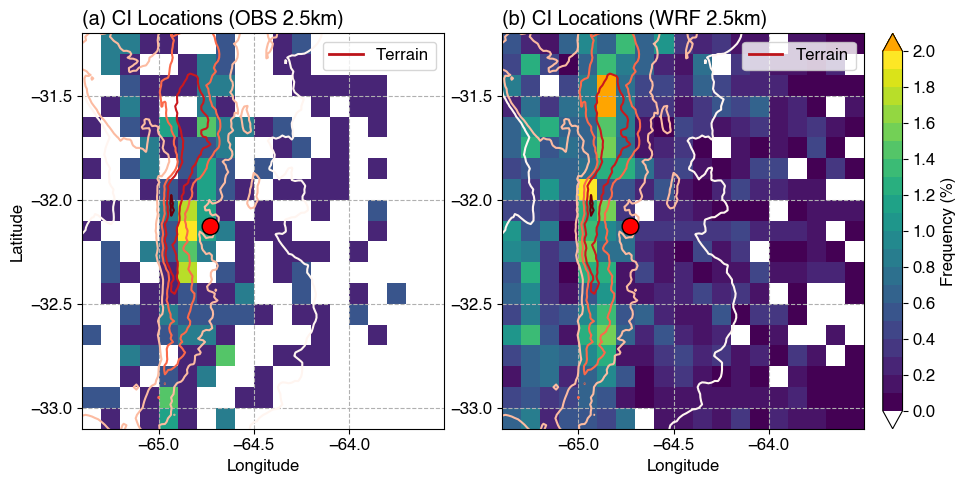

In [61]:
dataarr = [freq2d_startloc_nonsplit_o25, freq2d_startloc_nonsplit_d2]
levels = np.arange(0, 2.1, 0.1)
cbticks = np.arange(0, 2.1, 0.2)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under':'white', 'over':'orange'}
titles = ['(a) CI Locations (OBS 2.5km)', '(b) CI Locations (WRF 2.5km)']
cblabels = 'Frequency (%)'
figsize = [10.5,5]
figname = f'{figdir}celltrack_startend_loc_nonsplit_freq_0.1deg_obs2.5km_meso2.5km.png'
fig = plot_Nheatmaps(2, dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, cbticks, titles, figname, oob_colors=oob_colors, figsize=figsize)

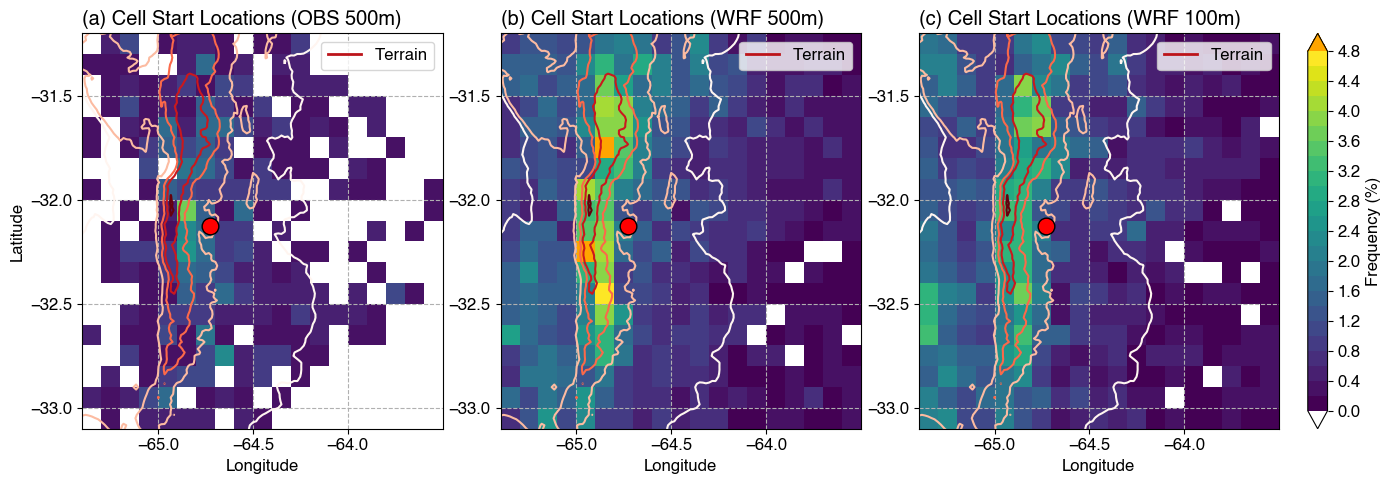

In [62]:
dataarr = [freq2d_startloc_o, freq2d_startloc_d3, freq2d_startloc_d4]
levels = np.arange(0, 4.81, 0.2)
cbticks = np.arange(0, 4.81, 0.4)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under':'white', 'over':'orange'}
titles = ['(a) Cell Start Locations (OBS 500m)', '(b) Cell Start Locations (WRF 500m)', '(c) Cell Start Locations (WRF 100m)']
cblabels = 'Frequency (%)'
figsize = [15.5,5]
figname = f'{figdir}celltrack_startend_loc_freq_0.1deg_obs_les_d3_d4.png'
fig = plot_Nheatmaps(3, dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, cbticks, titles, figname, oob_colors=oob_colors, figsize=figsize)

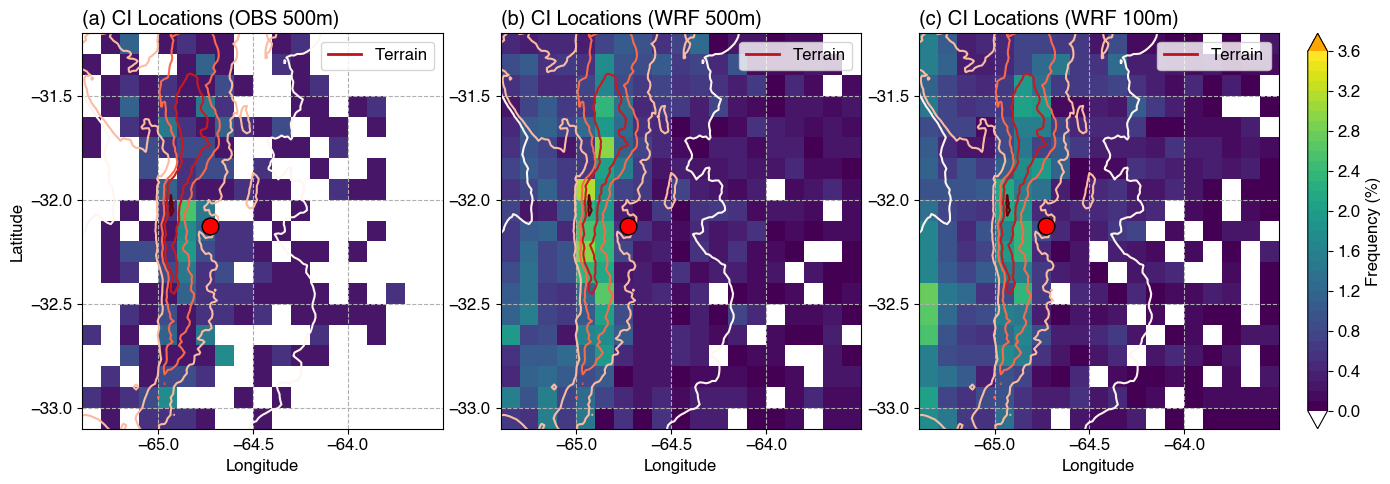

In [63]:
dataarr = [freq2d_startloc_nonsplit_o, freq2d_startloc_nonsplit_d3, freq2d_startloc_nonsplit_d4]
levels = np.arange(0, 3.61, 0.1)
cbticks = np.arange(0, 3.61, 0.4)
# levels = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0, 2.4, 3.0]
# cbticks = levels
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under':'white', 'over':'orange'}
titles = ['(a) CI Locations (OBS 500m)', '(b) CI Locations (WRF 500m)', '(c) CI Locations (WRF 100m)']
cblabels = 'Frequency (%)'
figsize = [15.5,5]
figname = f'{figdir}celltrack_startend_loc_nonsplit_freq_0.1deg_obs_les_d3_d4.png'
fig = plot_Nheatmaps(3, dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, cbticks, titles, figname, oob_colors=oob_colors, figsize=figsize)

In [64]:
figdir

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

In [65]:
bins_lifetime = np.arange(21)*0.25
bins_lifetime_c = bins_lifetime[:-1] + np.diff(bins_lifetime)/2
hist_lifetime_o, bins = np.histogram(lifetime_o, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_o, bins = np.histogram(lifetime_o.isel(tracks=nonmerge_o), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d3, bins = np.histogram(lifetime_d3, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d3, bins = np.histogram(lifetime_d3.isel(tracks=nonmerge_d3), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d4, bins = np.histogram(lifetime_d4, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d4, bins = np.histogram(lifetime_d4.isel(tracks=nonmerge_d4), bins=bins_lifetime, range=(0,5), density=True)

In [66]:
hist_lifetime_o25, bins = np.histogram(lifetime_o25, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_o25, bins = np.histogram(lifetime_o25.isel(tracks=nonmerge_o25), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d2, bins = np.histogram(lifetime_d2, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d2, bins = np.histogram(lifetime_d2.isel(tracks=nonmerge_d2), bins=bins_lifetime, range=(0,5), density=True)

In [67]:
bin_cellarea = np.arange(1, 3.01, 0.1)
bin_maxdbz = np.arange(10, 70.1, 2.5)
bin_ctt = np.arange(-100,10.1,5)
bin_eth = np.arange(0,20.1,1)

hist2d_cellarea_maxdbz_o, xbin, ybin = np.histogram2d(np.log10(cell_area_o).max(dim='times'), maxdbz_o.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_o, xbin, ybin = np.histogram2d(eth20_o.max(dim='times'), maxdbz_o.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_o, xbin, ybin = np.histogram2d(np.log10(cell_area_o).max(dim='times'), eth20_o.max(dim='times'), bins=[bin_cellarea, bin_eth])

In [68]:
hist2d_cellarea_maxdbz_o25, xbin, ybin = np.histogram2d(np.log10(cell_area_o25).max(dim='times'), maxdbz_o25.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_o25, xbin, ybin = np.histogram2d(eth20_o25.max(dim='times'), maxdbz_o25.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_o25, xbin, ybin = np.histogram2d(np.log10(cell_area_o25).max(dim='times'), eth20_o25.max(dim='times'), bins=[bin_cellarea, bin_eth])

In [69]:
hist2d_cellarea_maxdbz_d2, xbin, ybin = np.histogram2d(np.log10(cell_area_d2).max(dim='times'), maxdbz_d2.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_d2, xbin, ybin = np.histogram2d(eth20_d2.max(dim='times'), maxdbz_d2.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_d2, xbin, ybin = np.histogram2d(np.log10(cell_area_d2).max(dim='times'), eth20_d2.max(dim='times'), bins=[bin_cellarea, bin_eth])

In [70]:
hist2d_cellarea_maxdbz_d3, xbin, ybin = np.histogram2d(np.log10(cell_area_d3).max(dim='times'), maxdbz_d3.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_d3, xbin, ybin = np.histogram2d(eth20_d3.max(dim='times'), maxdbz_d3.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_d3, xbin, ybin = np.histogram2d(np.log10(cell_area_d3).max(dim='times'), eth20_d3.max(dim='times'), bins=[bin_cellarea, bin_eth])

In [71]:
hist2d_cellarea_maxdbz_d4, xbin, ybin = np.histogram2d(np.log10(cell_area_d4).max(dim='times'), maxdbz_d4.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_d4, xbin, ybin = np.histogram2d(eth20_d4.max(dim='times'), maxdbz_d4.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_d4, xbin, ybin = np.histogram2d(np.log10(cell_area_d4).max(dim='times'), eth20_d4.max(dim='times'), bins=[bin_cellarea, bin_eth])

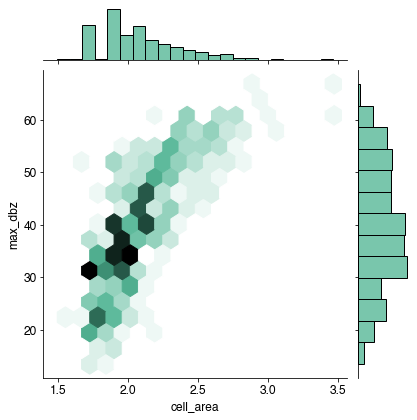

In [72]:
sns.jointplot(x=np.log10(cell_area_o25).max(dim='times'), y=maxdbz_o25.max(dim='times'), kind="hex", color="#4CB391")

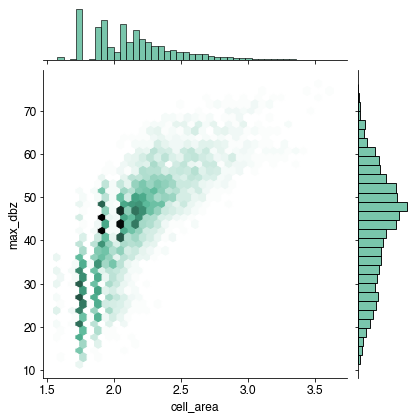

In [73]:
sns.jointplot(x=np.log10(cell_area_d2).max(dim='times'), y=maxdbz_d2.max(dim='times'), kind="hex", color="#4CB391")

In [74]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [75]:
lifetime_nomerge_o = lifetime_o.isel(tracks=nonmerge_o, drop=True)
ncells_nomerge_o = lifetime_nomerge_o.count().values
ncells_nomerge_gt30min_o = np.count_nonzero(lifetime_nomerge_o > 0.5)
ncells_nomerge_ge1hour_o = np.count_nonzero(lifetime_nomerge_o >= 1.0)
frac_nomerge_gt30min_o = 100 * ncells_nomerge_gt30min_o / ncells_nomerge_o
frac_nomerge_ge1hour_o = 100 * ncells_nomerge_ge1hour_o / ncells_nomerge_o
print(f'All non-merge cells (OBS): {ncells_nomerge_o}')
print(f'Non-merge cells (OBS) > 30 min: {ncells_nomerge_gt30min_o}')
print(f'Non-merge cells (OBS) >= 1 hour: {ncells_nomerge_ge1hour_o}')
print(f'Fraction of cells (OBS) (> 30 min): {frac_nomerge_gt30min_o}%')
print(f'Fraction of cells (OBS) (>= 1 hour): {frac_nomerge_ge1hour_o}%')

All non-merge cells (OBS): 373
Non-merge cells (OBS) > 30 min: 180
Non-merge cells (OBS) >= 1 hour: 113
Fraction of cells (OBS) (> 30 min): 48.257372654155496%
Fraction of cells (OBS) (>= 1 hour): 30.29490616621984%


In [76]:
lifetime_nomerge_o25 = lifetime_o25.isel(tracks=nonmerge_o25, drop=True)
ncells_nomerge_o25 = lifetime_nomerge_o25.count().values
ncells_nomerge_gt30min_o25 = np.count_nonzero(lifetime_nomerge_o25 > 0.5)
ncells_nomerge_ge1hour_o25 = np.count_nonzero(lifetime_nomerge_o25 >= 1.0)
frac_nomerge_gt30min_o25 = 100 * ncells_nomerge_gt30min_o25 / ncells_nomerge_o25
frac_nomerge_ge1hour_o25 = 100 * ncells_nomerge_ge1hour_o25 / ncells_nomerge_o25
print(f'All non-merge cells (OBS 2.5km): {ncells_nomerge_o25}')
print(f'Non-merge cells (OBS 2.5km) > 30 min: {ncells_nomerge_gt30min_o25}')
print(f'Non-merge cells (OBS 2.5km) >= 1 hour: {ncells_nomerge_ge1hour_o25}')
print(f'Fraction of cells (OBS 2.5km) (> 30 min): {frac_nomerge_gt30min_o25}%')
print(f'Fraction of cells (OBS 2.5km) (>= 1 hour): {frac_nomerge_ge1hour_o25}%')

All non-merge cells (OBS 2.5km): 342
Non-merge cells (OBS 2.5km) > 30 min: 169
Non-merge cells (OBS 2.5km) >= 1 hour: 114
Fraction of cells (OBS 2.5km) (> 30 min): 49.41520467836257%
Fraction of cells (OBS 2.5km) (>= 1 hour): 33.333333333333336%


In [77]:
lifetime_nomerge_d3 = lifetime_d3.isel(tracks=nonmerge_d3, drop=True)
ncells_nomerge_d3 = lifetime_nomerge_d3.count().values
ncells_nomerge_gt30min_d3 = np.count_nonzero(lifetime_nomerge_d3 > 0.5)
ncells_nomerge_ge1hour_d3 = np.count_nonzero(lifetime_nomerge_d3 >= 1.0)
frac_nomerge_gt30min_d3 = 100 * ncells_nomerge_gt30min_d3 / ncells_nomerge_d3
frac_nomerge_ge1hour_d3 = 100 * ncells_nomerge_ge1hour_d3 / ncells_nomerge_d3
print(f'All non-merge cells (D3): {ncells_nomerge_d3}')
print(f'Non-merge cells (D3) > 30 min: {ncells_nomerge_gt30min_d3}')
print(f'Non-merge cells (D3) >= 1 hour: {ncells_nomerge_ge1hour_d3}')
print(f'Fraction of cells (D3) (> 30 min): {frac_nomerge_gt30min_d3}%')
print(f'Fraction of cells (D3) (>= 1 hour): {frac_nomerge_ge1hour_d3}%')

All non-merge cells (D3): 3474
Non-merge cells (D3) > 30 min: 1477
Non-merge cells (D3) >= 1 hour: 905
Fraction of cells (D3) (> 30 min): 42.51583189407024%
Fraction of cells (D3) (>= 1 hour): 26.050662061024756%


In [78]:
lifetime_nomerge_d4 = lifetime_d4.isel(tracks=nonmerge_d4, drop=True)
ncells_nomerge_d4 = lifetime_nomerge_d4.count().values
ncells_nomerge_gt30min_d4 = np.count_nonzero(lifetime_nomerge_d4 > 0.5)
ncells_nomerge_ge1hour_d4 = np.count_nonzero(lifetime_nomerge_d4 >= 1.0)
frac_nomerge_gt30min_d4 = 100 * ncells_nomerge_gt30min_d4 / ncells_nomerge_d4
frac_nomerge_ge1hour_d4 = 100 * ncells_nomerge_ge1hour_d4 / ncells_nomerge_d4
print(f'All non-merge cells (D4): {ncells_nomerge_d4}')
print(f'Non-merge cells (D4) > 30 min: {ncells_nomerge_gt30min_d4}')
print(f'Non-merge cells (D4) >= 1 hour: {ncells_nomerge_ge1hour_d4}')
print(f'Fraction of cells (D4) (> 30 min): {frac_nomerge_gt30min_d4}%')
print(f'Fraction of cells (D4) (>= 1 hour): {frac_nomerge_ge1hour_d4}%')

All non-merge cells (D4): 3363
Non-merge cells (D4) > 30 min: 1539
Non-merge cells (D4) >= 1 hour: 972
Fraction of cells (D4) (> 30 min): 45.76271186440678%
Fraction of cells (D4) (>= 1 hour): 28.902765388046387%


In [79]:
figdir

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

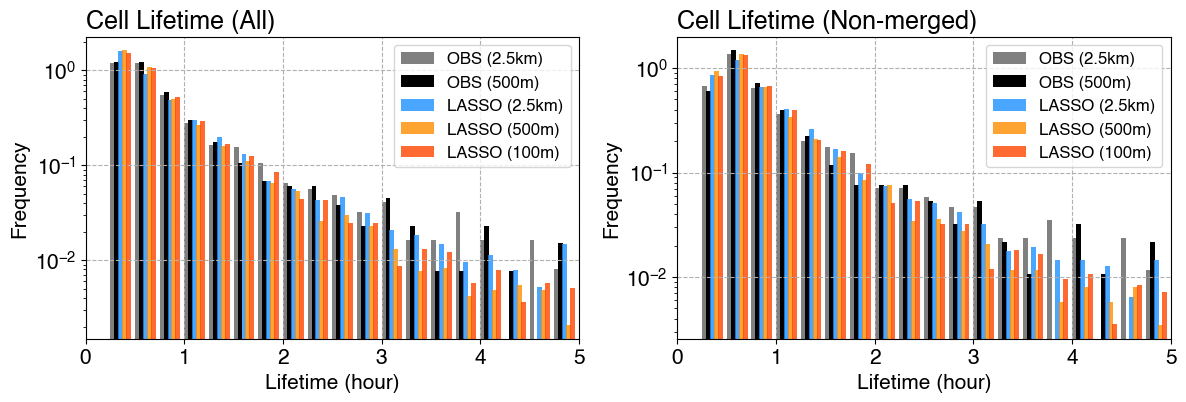

In [80]:
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

colors = {'obs':'k', 'obs25':'gray', 'd2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
bwidth = 0.05

ax1 = axes[0]
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
b0 = ax1.bar(bins_lifetime_c-0.10, hist_lifetime_o25, width=bwidth, color=colors['obs25'], label='OBS (2.5km)')
b1 = ax1.bar(bins_lifetime_c-0.06, hist_lifetime_o, width=bwidth, color=colors['obs'], label='OBS (500m)')
b2 = ax1.bar(bins_lifetime_c-0.02, hist_lifetime_d2, width=bwidth, color=colors['d2'], alpha=0.8, label='LASSO (2.5km)')
b3 = ax1.bar(bins_lifetime_c+0.02, hist_lifetime_d3, width=bwidth, color=colors['d3'], alpha=0.8, label='LASSO (500m)')
b4 = ax1.bar(bins_lifetime_c+0.06, hist_lifetime_d4, width=bwidth, color=colors['d4'], alpha=0.8, label='LASSO (100m)')
ax1.legend(fontsize=12)
ax1.set_xlim(0, 5)
ax1.set_title('Cell Lifetime (All)', loc='left')
ax1.grid(ls='--')
ax1.set_yscale('log')

ax2 = axes[1]
ax2.set_xlabel('Lifetime (hour)')
ax2.set_ylabel('Frequency')
b0 = ax2.bar(bins_lifetime_c-0.10, hist_lifetime_nonmerge_o25, width=bwidth, color=colors['obs25'], label='OBS (2.5km)')
b1 = ax2.bar(bins_lifetime_c-0.06, hist_lifetime_nonmerge_o, width=bwidth, color=colors['obs'], label='OBS (500m)')
b2 = ax2.bar(bins_lifetime_c-0.02, hist_lifetime_nonmerge_d2, width=bwidth, color=colors['d2'], alpha=0.8, label='LASSO (2.5km)')
b3 = ax2.bar(bins_lifetime_c+0.02, hist_lifetime_nonmerge_d3, width=bwidth, color=colors['d3'], alpha=0.8, label='LASSO (500m)')
b4 = ax2.bar(bins_lifetime_c+0.06, hist_lifetime_nonmerge_d4, width=bwidth, color=colors['d4'], alpha=0.8, label='LASSO (100m)')
ax2.legend(fontsize=12)
ax2.set_xlim(0, 5)
ax2.set_title('Cell Lifetime (Non-merged)', loc='left')
ax2.grid(ls='--')
ax2.set_yscale('log')
fig.savefig(f'{figdir}celltrack_lifetime_pdf_bars.png', bbox_inches='tight', dpi=300, facecolor='w')

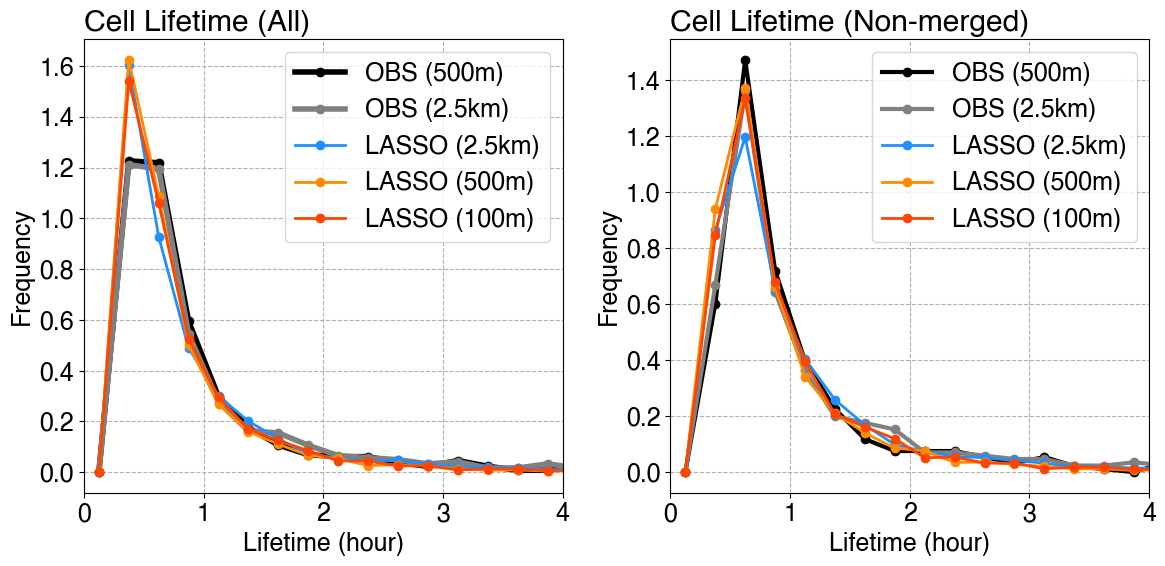

In [81]:
mpl.rcParams['font.size'] = 18
mpl.rcParams['font.family'] = 'Helvetica'
colors = {'obs':'k', 'obs25':'gray', 'd2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
lw = 2
marker = 'o'
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

ax0 = axes[0]
ax0.set_xlabel('Lifetime (hour)')
ax0.set_ylabel('Frequency')
b1 = ax0.plot(bins_lifetime_c, hist_lifetime_o, color=colors['obs'], marker=marker, lw=lw*2, label='OBS (500m)')
b0 = ax0.plot(bins_lifetime_c, hist_lifetime_o25, color=colors['obs25'], marker=marker, lw=lw*2, label='OBS (2.5km)')
b2 = ax0.plot(bins_lifetime_c, hist_lifetime_d2, color=colors['d2'], marker=marker, lw=lw, label='LASSO (2.5km)')
b3 = ax0.plot(bins_lifetime_c, hist_lifetime_d3, color=colors['d3'], marker=marker, lw=lw, label='LASSO (500m)')
b4 = ax0.plot(bins_lifetime_c, hist_lifetime_d4, color=colors['d4'], marker=marker, lw=lw, label='LASSO (100m)')
ax0.legend()
ax0.set_xlim(0, 4)
ax0.set_title('Cell Lifetime (All)', loc='left')
ax0.grid(ls='--')

ax1 = axes[1]
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
b1 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o, color=colors['obs'], marker=marker, lw=lw*1.5, label='OBS (500m)')
b0 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o25, color=colors['obs25'], marker=marker, lw=lw*1.5, label='OBS (2.5km)')
b2 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d2, color=colors['d2'], marker=marker, lw=lw, label='LASSO (2.5km)')
b3 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d3, color=colors['d3'], marker=marker, lw=lw, label='LASSO (500m)')
b4 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d4, color=colors['d4'], marker=marker, lw=lw, label='LASSO (100m)')
ax1.legend()
ax1.set_xlim(0, 4)
ax1.set_title('Cell Lifetime (Non-merged)', loc='left')
ax1.grid(ls='--')

fig.tight_layout()
fig.savefig(f'{figdir}celltrack_lifetime_pdf_lines.png', bbox_inches='tight', dpi=300, facecolor='w')

In [82]:
# mpl.rcParams['font.size'] = 15
# mpl.rcParams['font.family'] = 'Helvetica'
# fig, ax1 = plt.subplots(1, 1, figsize=(8, 5), dpi=100)

# colors = {'obs':'k', 'obs25':'gray', 'd2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
# lw = 3
# ax1.set_xlabel('Lifetime (hour)')
# ax1.set_ylabel('Frequency')
# b1 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o, color=colors['obs'], lw=lw*1.5, label='OBS (500m)')
# b0 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o25, color=colors['obs25'], lw=lw*1.5, label='OBS (2.5km)')
# b2 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d2, color=colors['d2'], lw=lw, label='LASSO (2.5km)')
# b3 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d3, color=colors['d3'], lw=lw, label='LASSO (500m)')
# b4 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d4, color=colors['d4'], lw=lw, label='LASSO (100m)')
# ax1.legend()
# ax1.set_xlim(0, 5)
# ax1.set_title('Cell Lifetime (Non-merged)', loc='left')
# ax1.grid(ls='--')
# # ax1.set_yscale('log')
# fig.savefig(f'{figdir}celltrack_lifetime_nonmerge_pdf_lines.png', bbox_inches='tight', dpi=300, facecolor='w')

## Function to compute 1D KDE

In [83]:
def get_kde1d(data, bins, kde_bw, kde_kernel='gaussian'):
    """
    Compute 1D KDE using Ski-learn
    
    Args:
        data: np.array
            Array containing data.
        bins: np.array
            Desired bins for plotting.
        kde_bw: float
            The bandwidth of the kernel.
        kde_kernel: string
            The kernel to use.
            
    Return:
        kde_out: np.array
            KDE at the desired bins.
    """
    # Flatten array to 1D
    data1d = data.flatten()
    # Remove NaN (sklearn KDE does not handle NaN), and make a new axis
    _data = data1d[~np.isnan(data1d)][:, np.newaxis]
    _bins = bins[:, np.newaxis]
    
    # Estimate 1D KDE following sklearn example
    # https://scikit-learn.org/stable/auto_examples/neighbors/plot_kde_1d.html
    kde = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(_data)
    # Get KDE values based on input bins
    log_dens = kde.score_samples(_bins)
    # Get linear density
    kde_out = np.exp(log_dens)
    return kde_out

In [84]:
lifetime_bins = np.linspace(0.25, 5, 1000)
kde_bw = 0.25
# All cells
kde_lifetime_o = get_kde1d(lifetime_o.data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_o25 = get_kde1d(lifetime_o25.data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_d2 = get_kde1d(lifetime_d2.data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_d3 = get_kde1d(lifetime_d3.data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_d4 = get_kde1d(lifetime_d4.data, lifetime_bins, kde_bw=kde_bw)
# Non-merge cells
kde_lifetime_nm_o = get_kde1d(lifetime_o.isel(tracks=nonmerge_o).data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_nm_o25 = get_kde1d(lifetime_o25.isel(tracks=nonmerge_o25).data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_nm_d2 = get_kde1d(lifetime_d2.isel(tracks=nonmerge_d2).data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_nm_d3 = get_kde1d(lifetime_d3.isel(tracks=nonmerge_d3).data, lifetime_bins, kde_bw=kde_bw)
kde_lifetime_nm_d4 = get_kde1d(lifetime_d4.isel(tracks=nonmerge_d4).data, lifetime_bins, kde_bw=kde_bw)

In [85]:
# fig, axes = plt.subplots(1, 2, figsize=[8,4], dpi=100)
# ax = axes[0]
# ax.plot(lifetime_bins, kde_lifetime_obs, 'k', lw=2)
# ax.plot(lifetime_bins, kde_lifetime_d3, 'b')
# ax.plot(lifetime_bins, kde_lifetime_d4, 'r')
# # ax.set_yscale('log')
# ax = axes[1]
# ax.plot(lifetime_bins, kde_lifetime_nm_obs, 'k', lw=2)
# ax.plot(lifetime_bins, kde_lifetime_nm_d3, 'b')
# ax.plot(lifetime_bins, kde_lifetime_nm_d4, 'r')

# Plot KDE of cell lifetime

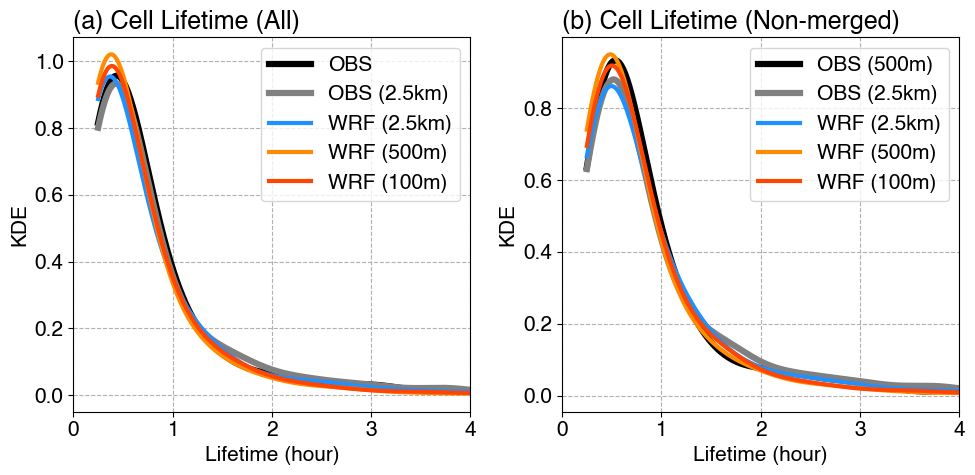

In [86]:
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

lw = 3
lcolors = {'o':'k', 'o25':'gray', 'd2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}

ax1 = axes[0]
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('KDE')
ax1.plot(lifetime_bins, kde_lifetime_o, color=lcolors['o'], lw=lw*1.5, label='OBS')
ax1.plot(lifetime_bins, kde_lifetime_o25, color=lcolors['o25'], lw=lw*1.5, label='OBS (2.5km)')
ax1.plot(lifetime_bins, kde_lifetime_d2, color=lcolors['d2'], lw=lw, label='WRF (2.5km)')
ax1.plot(lifetime_bins, kde_lifetime_d3, color=lcolors['d3'], lw=lw, label='WRF (500m)')
ax1.plot(lifetime_bins, kde_lifetime_d4, color=lcolors['d4'], lw=lw, label='WRF (100m)')
ax1.legend()
ax1.set_xlim(0, 4)
ax1.set_title('(a) Cell Lifetime (All)', loc='left')
ax1.grid(ls='--')

ax2 = axes[1]
ax2.set_xlabel('Lifetime (hour)')
ax2.set_ylabel('KDE')
ax2.plot(lifetime_bins, kde_lifetime_nm_o, color=lcolors['o'], lw=lw*1.5, label='OBS (500m)')
ax2.plot(lifetime_bins, kde_lifetime_nm_o25, color=lcolors['o25'], lw=lw*1.5, label='OBS (2.5km)')
ax2.plot(lifetime_bins, kde_lifetime_nm_d2, color=lcolors['d2'], lw=lw, label='WRF (2.5km)')
ax2.plot(lifetime_bins, kde_lifetime_nm_d3, color=lcolors['d3'], lw=lw, label='WRF (500m)')
ax2.plot(lifetime_bins, kde_lifetime_nm_d4, color=lcolors['d4'], lw=lw, label='WRF (100m)')
ax2.legend()
ax2.set_xlim(0, 4)
ax2.set_title('(b) Cell Lifetime (Non-merged)', loc='left')
ax2.grid(ls='--')

fig.tight_layout()
fig.savefig(f'{figdir}celltrack_lifetime_all_nonmerge_kde.png', bbox_inches='tight', dpi=300, facecolor='w')

In [87]:
figname

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/celltrack_startend_loc_nonsplit_freq_0.1deg_obs_les_d3_d4.png'

In [88]:
def plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname,
                   lcolors=None, legend_labels=None, legend_loc='lower right', cmap='Blues'):
    mpl.rcParams['font.family'] = 'Helvetica'
    g = sns.JointGrid(height=8, ratio=5, space=.3, marginal_ticks=False, xlim=xlim, ylim=ylim)

    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    cmap = truncate_colormap(cmap, 0.1, 1)
    sns.kdeplot(x=x_obs, y=y_obs, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=g.ax_joint)
    sns.kdeplot(x=x_m1, y=y_m1, color=lcolors['model'], levels=levels, fill=False, ax=g.ax_joint)
    sns.kdeplot(x=x_obs, color=lcolors['obs'], ax=g.ax_marg_x)
    sns.kdeplot(x=x_m1, color=lcolors['model'], ax=g.ax_marg_x)
    sns.kdeplot(y=y_obs, color=lcolors['obs'], ax=g.ax_marg_y)
    sns.kdeplot(y=y_m1, color=lcolors['model'], ax=g.ax_marg_y)
    legend_elements = [mpl.patches.Patch(facecolor=lcolors['obs'], edgecolor='b'),
                       mpl.lines.Line2D([0], [0], color=lcolors['model'])]
    leg = mpl.legend.Legend(g.ax_joint, handles=legend_elements, labels=legend_labels, 
                            loc=legend_loc, facecolor='w', prop={'family':'Helvetica', 'size':18})
    g.ax_joint.text(0.02, 0.95, annotate_text, ha='left', va='center', transform=g.ax_joint.transAxes)
    g.ax_joint.add_artist(leg)
    g.set_axis_labels(xlabel=xlabel, ylabel=ylabel)
    g.ax_marg_x.set_ylabel('')
    g.ax_marg_y.set_xlabel('')

    g.savefig(figname, dpi=300, facecolor='w')
    # sns.JointGrid(marginal_ticks=True)
    return g

In [89]:
# Set Seaborn plot style
sns.set_theme('talk', style='whitegrid', font_scale=1.3, 
              rc={'lines.linewidth':5, 'font.family':'Helvetica', 'axes.edgecolor':'k', 'grid.linestyle':'--'})

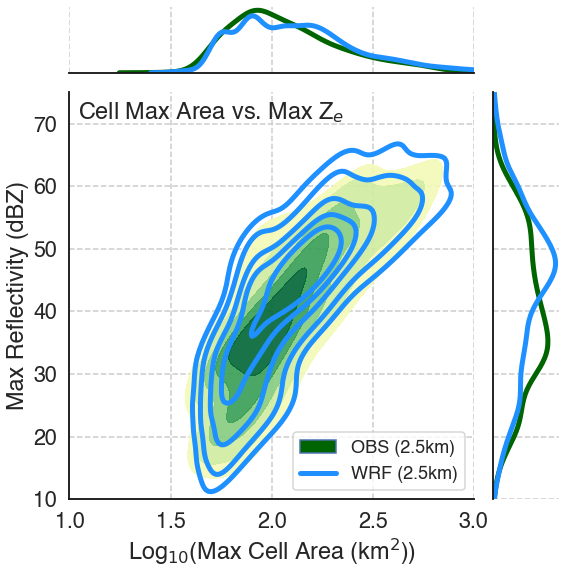

In [90]:
x_obs, y_obs = np.log10(cell_area_o25).max(dim='times').data, maxdbz_o25.max(dim='times').data
x_m, y_m = np.log10(cell_area_d2).max(dim='times').data, maxdbz_d2.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,3)
ylim = (10,75)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max Area vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
cmap = 'YlGn'
figname = f'{figdir}KDE_MaxArea_MaxDBZ_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

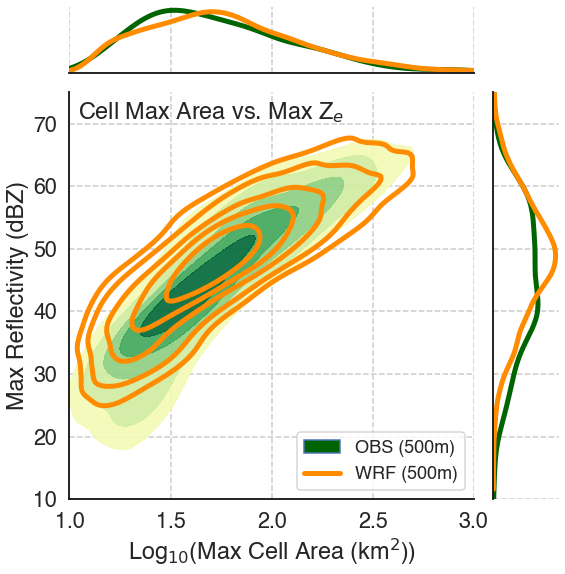

In [91]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d3).max(dim='times').data, maxdbz_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,3)
ylim = (10,75)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max Area vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'darkorange'}
legend_labels = ['OBS (500m)', 'WRF (500m)']
# cmap = 'YlGn'
figname = f'{figdir}KDE_MaxArea_MaxDBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

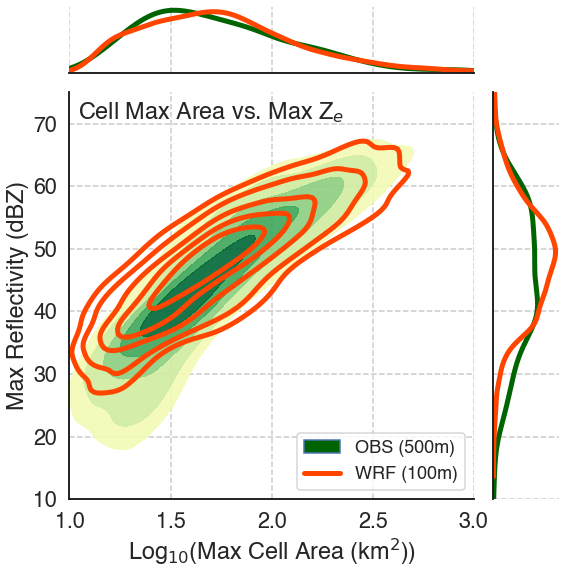

In [92]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d4).max(dim='times').data, maxdbz_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,3)
ylim = (10,75)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max Area vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'orangered'}
legend_labels = ['OBS (500m)', 'WRF (100m)']
# cmap = 'YlGn_r'
figname = f'{figdir}KDE_MaxArea_MaxDBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

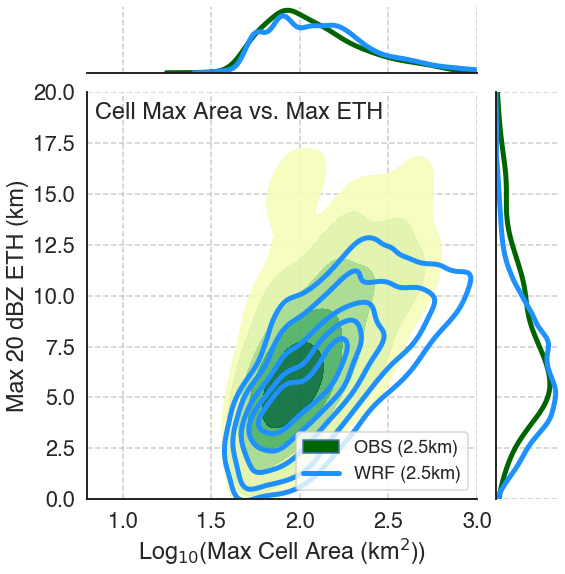

In [93]:
x_obs, y_obs = np.log10(cell_area_o25).max(dim='times').data, eth20_o25.max(dim='times').data
x_m, y_m = np.log10(cell_area_d2).max(dim='times').data, eth20_d2.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0.8,3)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 20 dBZ ETH (km)'
annotate_text = 'Cell Max Area vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
figname = f'{figdir}KDE_MaxArea_MaxETH20dBZ_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

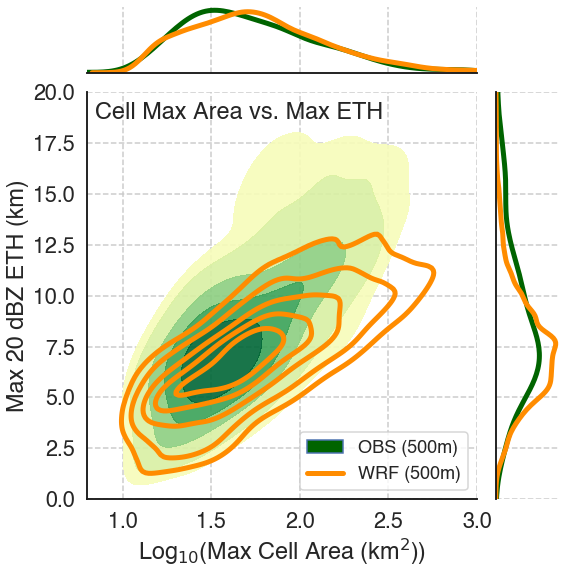

In [94]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, eth20_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d3).max(dim='times').data, eth20_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0.8,3)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 20 dBZ ETH (km)'
annotate_text = 'Cell Max Area vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'darkorange'}
legend_labels = ['OBS (500m)', 'WRF (500m)']
figname = f'{figdir}KDE_MaxArea_MaxETH20dBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

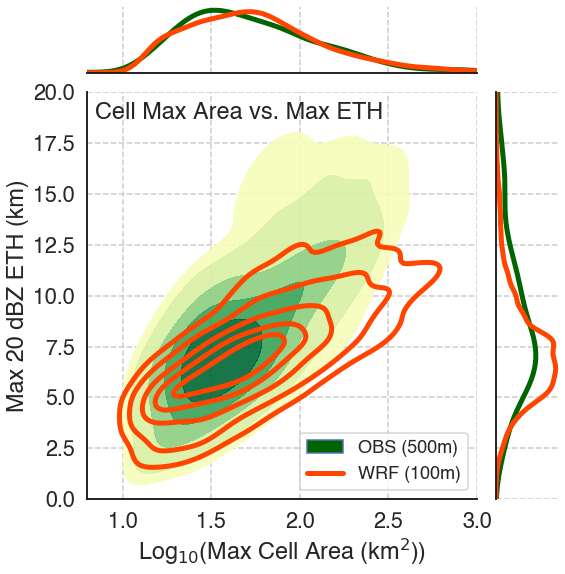

In [95]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, eth20_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d4).max(dim='times').data, eth20_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0.8,3)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 20 dBZ ETH (km)'
annotate_text = 'Cell Max Area vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'orangered'}
legend_labels = ['OBS (500m)', 'WRF (100m)']
figname = f'{figdir}KDE_MaxArea_MaxETH20dBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

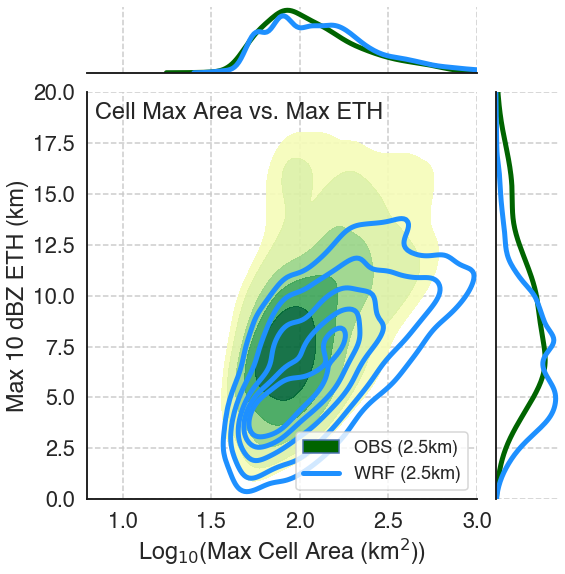

In [96]:
x_obs, y_obs = np.log10(cell_area_o25).max(dim='times').data, eth10_o25.max(dim='times').data
x_m, y_m = np.log10(cell_area_d2).max(dim='times').data, eth10_d2.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0.8,3)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 10 dBZ ETH (km)'
annotate_text = 'Cell Max Area vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
figname = f'{figdir}KDE_MaxArea_MaxETH10dBZ_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

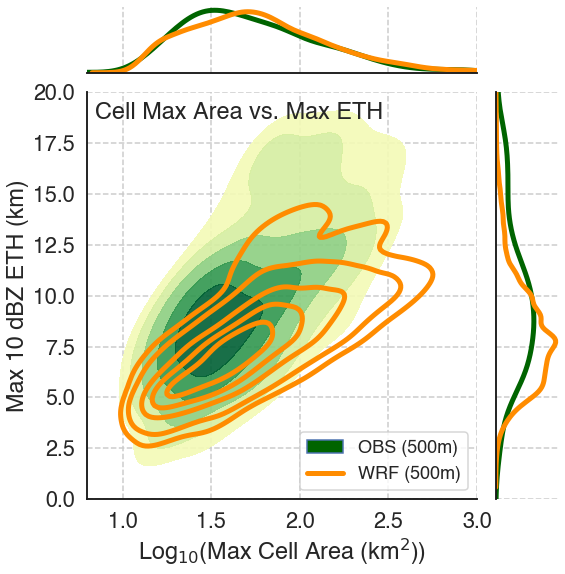

In [97]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, eth10_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d3).max(dim='times').data, eth10_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0.8,3)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 10 dBZ ETH (km)'
annotate_text = 'Cell Max Area vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'darkorange'}
legend_labels = ['OBS (500m)', 'WRF (500m)']
figname = f'{figdir}KDE_MaxArea_MaxETH10dBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

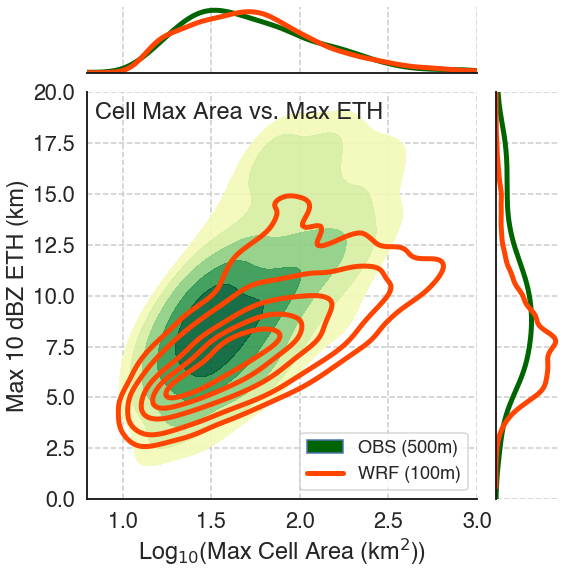

In [98]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, eth10_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d4).max(dim='times').data, eth10_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0.8,3)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 10 dBZ ETH (km)'
annotate_text = 'Cell Max Area vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'orangered'}
legend_labels = ['OBS (500m)', 'WRF (100m)']
figname = f'{figdir}KDE_MaxArea_MaxETH10dBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

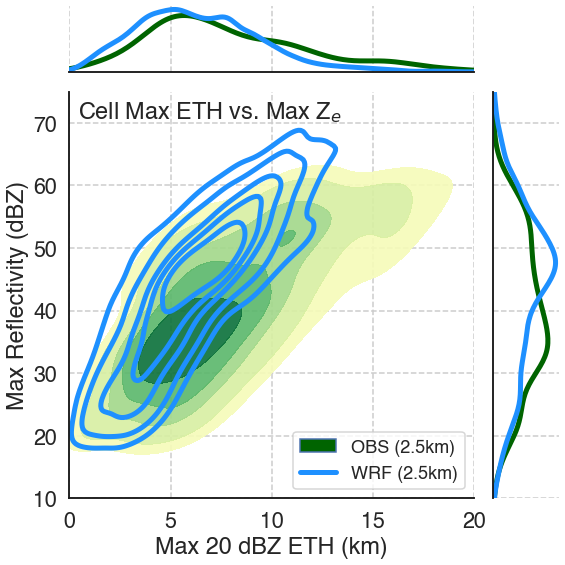

In [99]:
x_obs, y_obs = eth20_o25.max(dim='times').data, maxdbz_o25.max(dim='times').data
x_m, y_m = eth20_d2.max(dim='times').data, maxdbz_d2.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,20)
ylim = (10,75)
xlabel = 'Max 20 dBZ ETH (km)'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max ETH vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
figname = f'{figdir}KDE_MaxETH20dBZ_MaxDBZ_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

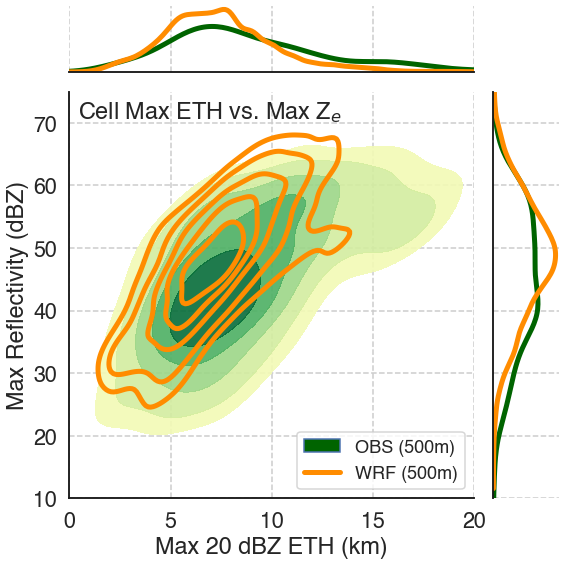

In [100]:
x_obs, y_obs = eth20_o.max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = eth20_d3.max(dim='times').data, maxdbz_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,20)
ylim = (10,75)
xlabel = 'Max 20 dBZ ETH (km)'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max ETH vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'darkorange'}
legend_labels = ['OBS (500m)', 'WRF (500m)']
figname = f'{figdir}KDE_MaxETH20dBZ_MaxDBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

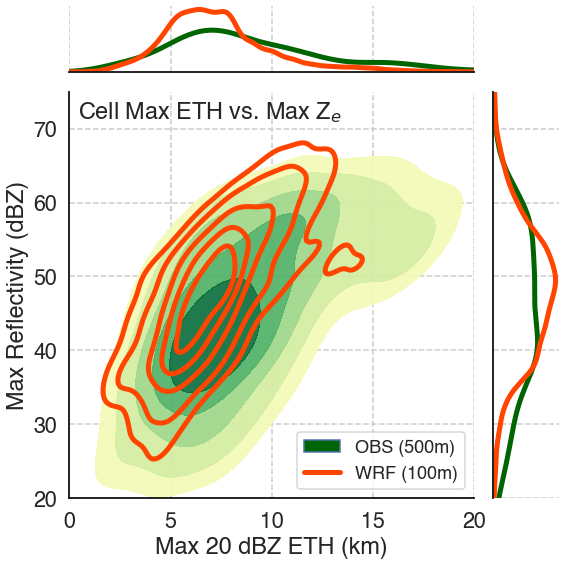

In [101]:
x_obs, y_obs = eth20_o.max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = eth20_d4.max(dim='times').data, maxdbz_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,20)
ylim = (20,75)
xlabel = 'Max 20 dBZ ETH (km)'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max ETH vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'orangered'}
legend_labels = ['OBS (500m)', 'WRF (100m)']
figname = f'{figdir}KDE_MaxETH20dBZ_MaxDBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap)

In [102]:
figdir

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'